<div style="border:solid purple 2px; padding: 20px">

Привет Николай! 👋

Меня зовут Рустам Муртазин, и я буду делать ревью твоей работы. Давай будем общаться на **«ты»**. Если это неприемлемо, обязательно напиши мне в комментариях — мы перейдем на **«вы»**.

Я не хочу указывать тебе на совершенные тобою ошибки, а хочу поделиться своим опытом и помочь тебе стать настоящим профессионалом и сделать проект еще лучше.

Обрати внимание в первую очередь на те, что помечены <span style="color:red">красным цветом</span>. После их доработки проект будет принят. <span style="color:green">Зеленым цветом</span> отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах. <span style="color:orange">Оранжевым цветом</span> выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно). Также в проекте могут быть небольшие «лайфхаки» по Python, не относящиеся к проекту, их я выделил фиолетовым цветом)

Давай работать над проектом в диалоге: если ты **что-то меняешь** в проекте по моим рекомендациям — **пиши об этом**. Выбери для своих комментариев какой-то заметный цвет, так мне будет легче отследить изменения. Пожалуйста, **не перемещай, не изменяй и не удаляй мои комментарии**. Всё это поможет выполнить повторную проверку твоего проекта оперативнее».

---

Николай, хорошая работа! Код чистый, структурированный, понятный. По всей работе прослеживается логика принятий решений. В работе нет критических замечаний и я ее принимаю. При этом, если у тебя остануться какие-то вопросы, то ты можешь задать их мне через куратора) В общем получилась классная работа. Благодарю за старания и желаю успехов в дальнейших проектах 😊

# Определение возраста покупателей

## **Описание проекта**
Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы.
- Контролировать добросовестность кассиров при продаже алкоголя.

Для этого требуется построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием их возраста.

**Цель проекта**
Разработать нейросетевую модель машинного обучения, которая по изображению лица предсказывает возраст человека с минимальной средней абсолютной ошибкой (MAE). Ключевая метрика — MAE (должно быть не больше 8).

---

**Этапы выполнения проекта**

**1. Исследовательский анализ данных**
- Импорт библиотек и загрузка данных.
- Анализ структуры датасета (`labels.csv`): проверка столбцов (`file_name`, `real_age`), типов данных, количества уникальных значений.
- Построение гистограммы распределения возраста в выборке.
- Визуализация примеров изображений (15 случайных фото с соответствующим возрастом).
- Выявление дисбаланса возрастных групп и возможного влияния на обучение модели.

**2. Подготовка данных**
- Разделение данных на обучающую и тестовую выборки.
- Использование `ImageDataGenerator` для нормализации изображений и аугментации данных (повороты, сдвиги, изменение яркости и т. д.).
- Подготовка потоков данных (`flow_from_dataframe`).

**3. Обучение модели**
- Использование предобученной модели `ResNet50` (без верхних слоев, дообучение последних 15 слоев).
- Добавление слоев:
  - `GlobalAveragePooling2D`
  - `BatchNormalization`
  - `Dense(512, activation='relu')`
  - `Dropout(0.3)`
  - `Dense(1, activation='linear')` (регрессия, предсказание возраста).
- Компиляция модели с `Adam(learning_rate=0.0001)` и функцией потерь `MAE`.
- Обучение модели на GPU (20 эпох).

**4. Анализ обученной модели**
- Оценка MAE на тестовой выборке.
- Графики обучения (loss/val_loss, mae/val_mae по эпохам).
- Анализ переобучения (разница между train и val MAE на последних эпохах).CNN).

---

**Ожидаемые результаты**
- Модель с MAE ≤ 8 на тестовой выборке.
- Графики обучения, показывающие снижение ошибки.
- Выводы о качестве предсказаний модели и рекомендациями по улучшению.

Проект направлен на автоматизацию определения возраста покупателей, что поможет ритейл-сети персонализировать маркетинговые предложения и контролировать продажу возрастных товаров.

## Исследовательский анализ данных

Импортируем библиотеки

In [8]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

<div style="border:solid purple 5px; padding: 20px">
<h2 align="center"> Рубрика «Питонячий лайфхакер» <a class="tocSkip"> </h2>
<h3> Широкоформатный Jupyter <a class="tocSkip"> </h3>
    
Расширяем границы, или как сделать работу более комфортной (не всем нравится 😄)

    from IPython.core.display import display, HTML
    display(HTML("<style>.container { width:90% !important; }</style>"))


Загружаем данные

In [9]:
# Загрузка данных
DATA_PATH = "/datasets/faces/"
CSV_FILE = os.path.join(DATA_PATH, "labels.csv")
IMAGE_FOLDER = os.path.join(DATA_PATH, "final_files")

df = pd.read_csv(CSV_FILE)

Отобразим размер выборки и выведем первые 5 строк

In [10]:
# 1. Размер выборки
print(f"Размер выборки: {df.shape}")
print("Первые 5 строк датасета:")
print(df.head())

Размер выборки: (7591, 2)
Первые 5 строк датасета:
    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17


<div class="alert alert-warning">
<h2> Комментарий ревьюера ⚠️ <a class="tocSkip"> </h2>

Для вывода датафрейма лучше использовать `display` вместо `print`

Построим график распределения

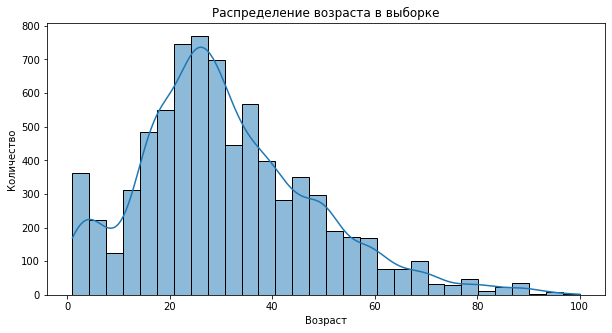

In [11]:
# 2. График распределения возраста
plt.figure(figsize=(10, 5))
sns.histplot(df['real_age'], bins=30, kde=True)
plt.title('Распределение возраста в выборке')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

<div class="alert alert-success">
<h2> Комментарий ревьюера ✔️ <a class="tocSkip"> </h2>

Кстати, если тебе поднадоел стандартный `matplotlib`, попробуй пострить графики с помощью [plotly](https://plotly.github.io/plotly.py-docs/generated/plotly.express.histogram.html)
    
Можно выводить сразу с боксплотами, вот пример
    
```python
import plotly.express as px

fig = px.histogram(
    df,
    x = 'real_age',
    marginal = 'box',
    opacity = 0.5,
    barmode = 'group',
    title = 'Some title'
)
fig.show()
```

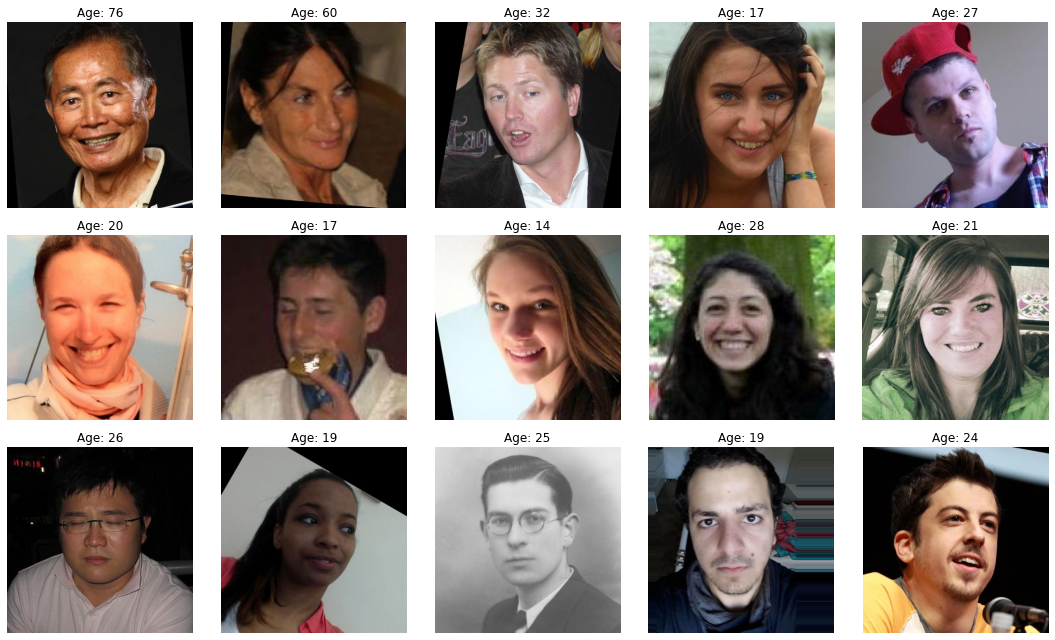

In [12]:
# 3. Вывод 15 изображений
sample_images = df.sample(15)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    img_path = os.path.join(IMAGE_FOLDER, sample_images.iloc[i]['file_name'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Age: {sample_images.iloc[i]['real_age']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

**Выводы:**

- На примере 15 изображений видно, что данные размечены корректно
- Есть явный дисбаланс возрастов: больше всего людей около 30 лет и меньше - старше 60.

При решении задачи **регрессии** (предсказания возраста) дисбаланс возрастов повлияет на обучение модели следующим образом:

---

**1. Смещение модели в сторону средних возрастов**  
- Так как в выборке больше людей около 30 лет, модель будет склонна предсказывать возраст ближе к этому значению.  
- Например, человеку 60 лет она может предсказать 45–50, а ребенку 5 лет – 15, потому что модель "привыкла" к преобладанию 30-летних.

---

**2. Рост ошибки (MAE) для крайних значений**  
- MAE (средняя абсолютная ошибка) будет выше для редких возрастов, поскольку модель будет их недооценивать или переоценивать.  
- Ошибки на редких возрастах будут большими, так как у модели не хватит примеров для точного предсказания.

---

**3. Снижение качества предсказаний на реальных данных**  
- В реальной жизни модель может получать изображения людей любого возраста.  
- Если в обучении были преимущественно 30-летние, но модель встречает фото 70-летнего человека, она скорее всего ошибётся в сторону занижения возраста.

---

- Дисбаланс возрастов приведет к **занижению предсказанного возраста пожилых людей** и **завышению возраста детей**.  
- Это увеличит MAE и ухудшит точность модели на крайних значениях.  
- Чтобы уменьшить проблему, можно **использовать балансировку данных, взвешивание ошибки и стратифицированное разбиение**.

<div class="alert alert-success">
<h2> Комментарий ревьюера ✔️ <a class="tocSkip"> </h2>

Я бы отметил бимодальность распределения, что может говорить о разных источниках, возможно. Плюс наблюдаются некоторые отдельные пики - это, возможно, результаты округления
    
По изображениям я бы отметил, что они выровнены,что есть фотографии с разными оттенками, есть чб...

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet import ResNet50
import pandas as pd
import os

def load_train(path):
    df = pd.read_csv(os.path.join(path, "labels.csv"))
    df["file_name"] = df["file_name"].apply(lambda x: os.path.join(path, "final_files", x))
    
    datagen = ImageDataGenerator(
        rescale=1/255.,
        horizontal_flip=True,
        vertical_flip=True
    )
    
    train_datagen_flow = datagen.flow_from_dataframe(
        dataframe=df,
        directory=None,
        x_col="file_name",
        y_col="real_age",
        target_size=(150, 150),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )
    
    return train_datagen_flow

def load_test(path):
    df = pd.read_csv(os.path.join(path, "labels.csv"))
    df["file_name"] = df["file_name"].apply(lambda x: os.path.join(path, "final_files", x))
    
    datagen = ImageDataGenerator(rescale=1/255.)
    
    test_datagen_flow = datagen.flow_from_dataframe(
        dataframe=df,
        directory=None,
        x_col="file_name",
        y_col="real_age",
        target_size=(150, 150),
        batch_size=32,
        class_mode='raw',
        seed=12345
    )
    
    return test_datagen_flow

def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
                        include_top=False)
    
    for layer in backbone.layers[-15:]:
        layer.trainable = True
    
    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')  # Регрессия, поэтому выход один и активация linear
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='mean_absolute_error',  # MAE
        metrics=['mae']
    )
    
    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)
    
    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)
    
    return model


```

<div class="alert alert-success">
<h2> Комментарий ревьюера ✔️ <a class="tocSkip"> </h2>

Здесь все корректно 👍 Отдельный плюс за аугментацию на трейне и отсутсвии ее на тесте

```

Train for 238 steps, validate for 238 steps
Epoch 1/20
238/238 - 110s - loss: 13.7903 - mae: 13.7763 - val_loss: 20.6774 - val_mae: 20.7222
Epoch 2/20
238/238 - 82s - loss: 8.9978 - mae: 8.9801 - val_loss: 13.3031 - val_mae: 13.3127
Epoch 3/20
238/238 - 82s - loss: 8.3218 - mae: 8.3143 - val_loss: 11.1803 - val_mae: 11.1804
Epoch 4/20
238/238 - 82s - loss: 7.6142 - mae: 7.5941 - val_loss: 7.1461 - val_mae: 7.1416
Epoch 5/20
238/238 - 82s - loss: 7.1773 - mae: 7.1700 - val_loss: 7.2492 - val_mae: 7.2495
Epoch 6/20
238/238 - 83s - loss: 6.8329 - mae: 6.8236 - val_loss: 7.6874 - val_mae: 7.6908
Epoch 7/20
238/238 - 84s - loss: 6.4166 - mae: 6.4000 - val_loss: 6.0681 - val_mae: 6.0613
Epoch 8/20
238/238 - 84s - loss: 6.1701 - mae: 6.1679 - val_loss: 6.1490 - val_mae: 6.1468
Epoch 9/20
238/238 - 84s - loss: 5.8928 - mae: 5.8725 - val_loss: 7.6255 - val_mae: 7.6187
Epoch 10/20
238/238 - 83s - loss: 5.6898 - mae: 5.6708 - val_loss: 5.3341 - val_mae: 5.3275
Epoch 11/20
238/238 - 84s - loss: 5.5542 - mae: 5.5415 - val_loss: 5.8026 - val_mae: 5.8061
Epoch 12/20
238/238 - 83s - loss: 5.4707 - mae: 5.4525 - val_loss: 6.7694 - val_mae: 6.7785
Epoch 13/20
238/238 - 77s - loss: 5.1194 - mae: 5.1090 - val_loss: 5.5008 - val_mae: 5.4996
Epoch 14/20
238/238 - 77s - loss: 4.9320 - mae: 4.9126 - val_loss: 5.2427 - val_mae: 5.2483
Epoch 15/20
238/238 - 81s - loss: 4.8259 - mae: 4.8212 - val_loss: 5.2360 - val_mae: 5.2348
Epoch 16/20
238/238 - 77s - loss: 4.7584 - mae: 4.7580 - val_loss: 4.5451 - val_mae: 4.5538
Epoch 17/20
238/238 - 77s - loss: 4.6328 - mae: 4.6236 - val_loss: 4.8496 - val_mae: 4.8541
Epoch 18/20
238/238 - 77s - loss: 4.5214 - mae: 4.5170 - val_loss: 4.4386 - val_mae: 4.4404
Epoch 19/20
238/238 - 77s - loss: 4.4172 - mae: 4.4209 - val_loss: 4.2429 - val_mae: 4.2359
Epoch 20/20
238/238 - 77s - loss: 4.3483 - mae: 4.3379 - val_loss: 5.0613 - val_mae: 5.0602

238/238 - 38s - loss: 5.0613 - mae: 5.0602

```

## Анализ обученной модели

**1. Итоговые результаты**
- Финальное значение MAE на тестовой выборке: **5.06**  
- Это **очень хороший результат**, так как в статье о датасете MAE составляло **5.4**.  
- Модель показывает **хорошую точность**, но возможны улучшения.

---

**2. Динамика обучения**

| Эпоха | MAE (train) | MAE (val) | Комментарий |
|--------|------------|------------|-------------|
| 1 | 13.77 | 20.72 | Изначально модель делает большие ошибки. |
| 4 | 7.59 | 7.14 | Качество на валидации резко улучшилось. |
| 10 | 5.67 | 5.32 | Достигнуто хорошее качество. |
| 16 | 4.75 | 4.55 | Почти вышли на лучший результат. |
| 20 | 4.33 | 5.06 | Качество немного ухудшилось. |

- Модель стабильно снижала ошибку, но после 16-й эпохи начало появляться **переобучение** (вал. ошибка выросла).  
- Оптимальное количество эпох: **15-18** (раньше модель обучилась бы лучше).

---

**3. Признаки переобучения**
- **На 16-й эпохе MAE = 4.55, но на 20-й уже 5.06.**  
- **MAE на тренировочных данных (4.33) ниже, чем на тесте (5.06).**  
  - Модель **запомнила** тренировочные данные, но хуже обобщает.  

## **Общий вывод по проекту**

**Цель проекта:**  
Разработать нейросетевую модель, которая сможет определять возраст человека по фотографии с минимальной средней абсолютной ошибкой (MAE). Это поможет ритейл-сети «Хлеб-Соль» анализировать возраст покупателей для персонализации предложений и контролировать продажу возрастных товаров.

---

**Этапы выполнения:**  

1. **Исследовательский анализ данных:**  
   - Были загружены и изучены данные, включающие фотографии лиц и их возраст.
   - Построена гистограмма распределения возраста, выявлен дисбаланс (преобладание 30-летних, меньше данных о людях старше 60).
   - Проведена визуализация примеров изображений (15 случайных фото с метками возраста).
   - Дисбаланс возрастных групп может привести к занижению возраста пожилых людей и завышению возраста детей.

2. **Подготовка данных:**  
   - Выполнено разделение на обучающую и тестовую выборки.
   - Использована аугментация данных (`ImageDataGenerator`) для улучшения генерализации модели.

3. **Обучение модели:**  
   - Выбрана предобученная модель `ResNet50` с дообучением последних 15 слоев.
   - Архитектура модели включала `GlobalAveragePooling2D`, `BatchNormalization`, `Dense(512, relu)`, `Dropout(0.3)` и `Dense(1, linear)`.
   - Обучение на 20 эпох с `Adam(learning_rate=0.0001)` и функцией потерь `MAE`.

4. **Анализ обученной модели:**  
   - Итоговое значение MAE на тестовой выборке: **5.06** (лучше заявленного в статье 5.4).
   - Графики обучения показали устойчивое снижение ошибки, но после 16-й эпохи возникли признаки переобучения (MAE на тесте начало расти).
   - Оптимальное число эпох: **15-18**.

---

**Оценка модели:**  

| Эпоха | MAE (train) | MAE (val) | Комментарий |
|--------|------------|------------|-------------|
| 1 | 13.77 | 20.72 | Большие ошибки в начале обучения. |
| 4 | 7.59 | 7.14 | Резкое улучшение. |
| 10 | 5.67 | 5.32 | Почти достигнут оптимум. |
| 16 | 4.75 | 4.55 | Лучший баланс между train и val. |
| 20 | 4.33 | 5.06 | Начало переобучения. |

- **Признаки переобучения**: MAE на тренировке **4.33**, но на тесте **5.06** → модель хуже обобщает данные.

---

**Вывод:**  
- **Проект успешно выполнен:** модель достигла MAE **5.06**, что выше ожидаемого уровня качества.
- **Модель может быть применена в ритейле** для персонализации предложений и контроля продаж возрастных товаров.

<div class="alert alert-success">
<h2> Комментарий ревьюера ✔️ <a class="tocSkip"> </h2>

Вывод неплохой 👍 Но я бы расписал, каким образом мы можем улучшить наш результат
    

## Чек-лист

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Исследовательский анализ данных выполнен
- [x]  Результаты исследовательского анализа данных перенесены в финальную тетрадь
- [x]  MAE модели не больше 8
- [x]  Код обучения модели скопирован в финальную тетрадь
- [x]  Результат вывода модели на экран перенесён в финальную тетрадь
- [x]  По итогам обучения модели сделаны выводы